In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

In [7]:
X_train[0].shape

(28, 28)

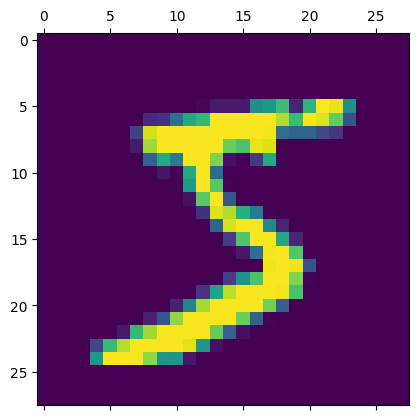

In [8]:
plt.matshow(X_train[0])

In [9]:
y_train[0]

np.uint8(5)

In [10]:
X_train = X_train / 255
X_test = X_test / 255

In [11]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [12]:
X_train_flattened.shape

(60000, 784)

In [13]:
cnn_model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

model_fit = cnn_model.fit(X_train_reshaped, y_train, epochs=5, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - accuracy: 0.9516 - loss: 0.1618 - val_accuracy: 0.9826 - val_loss: 0.0623
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9838 - loss: 0.0516 - val_accuracy: 0.9853 - val_loss: 0.0485
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9915 - loss: 0.0265 - val_accuracy: 0.9888 - val_loss: 0.0398
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9850 - val_loss: 0.0512


In [15]:
cnn_model.evaluate(X_test_reshaped, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9865 - loss: 0.0434


[0.043385472148656845, 0.9865000247955322]

In [19]:
y_pred = cnn_model.predict(X_test_reshaped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [20]:
y_pred_labels = [np.argmax(i) for i in y_pred]

In [21]:
y_pred_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [22]:
import numpy as np
predicted_class = np.argmax(y_pred[0])

In [23]:
predicted_class

np.int64(7)

In [24]:
y_pred[0]

array([3.0044613e-11, 4.1762752e-10, 4.0295401e-08, 1.2583731e-06,
       7.5388610e-12, 1.5366493e-11, 1.1246896e-14, 9.9999863e-01,
       2.9538647e-09, 1.7462169e-08], dtype=float32)

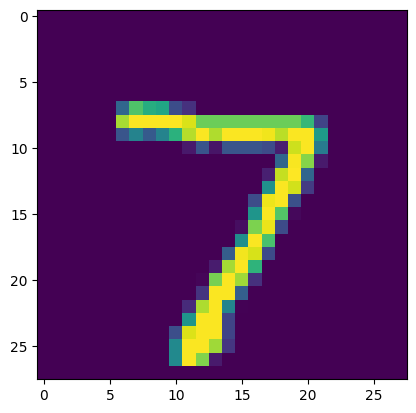

In [25]:
plt.imshow(X_test[0].reshape(28,28))
plt.show()

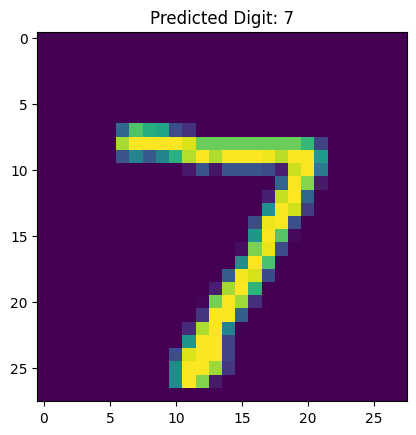

In [26]:
plt.imshow(X_test[0].reshape(28,28))

plt.title(f"Predicted Digit: {y_pred_labels[0]}")

plt.show()

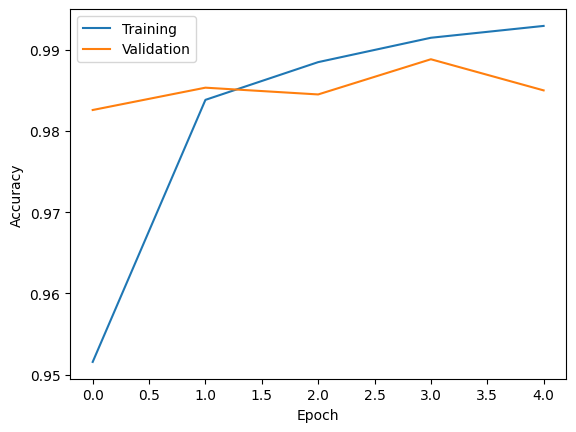

In [27]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

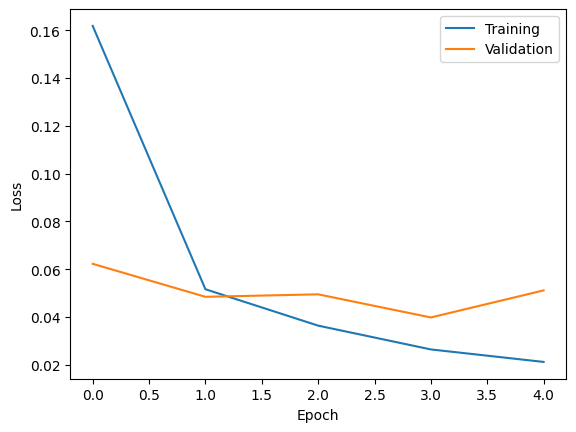

In [29]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_labels)
cm

array([[ 974,    1,    0,    1,    0,    1,    0,    2,    1,    0],
       [   0, 1129,    1,    4,    0,    0,    0,    1,    0,    0],
       [   2,    0, 1005,    5,    0,    0,    0,   19,    1,    0],
       [   0,    0,    1, 1009,    0,    0,    0,    0,    0,    0],
       [   0,    1,    0,    0,  973,    0,    1,    3,    0,    4],
       [   1,    0,    0,   10,    0,  877,    1,    1,    1,    1],
       [   4,    3,    2,    1,    2,    7,  937,    0,    2,    0],
       [   0,    0,    1,    1,    0,    0,    0, 1025,    0,    1],
       [   4,    0,    1,   10,    1,    2,    0,    4,  951,    1],
       [   0,    2,    0,    8,    3,    6,    0,    5,    0,  985]])

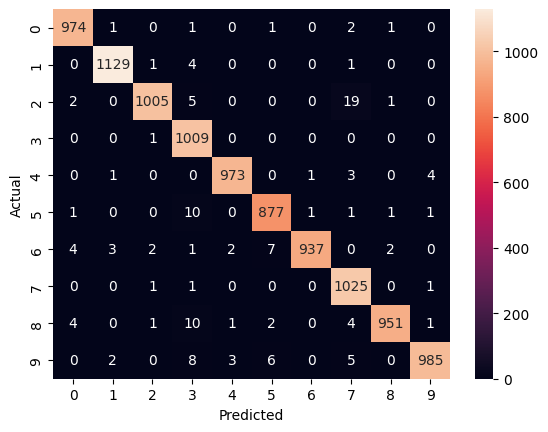

In [32]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()